In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# Load data
df = pd.read_csv("C:/Users/HP/Desktop/Internship Final Submission/NLP/2_raw_jobs.csv")
df = df.dropna(subset=["job_description"]).reset_index(drop=True)

In [3]:
# Basic text cleaning to create clean_description
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)       # remove URLs
    text = re.sub(r"[^a-z\s\+\#]", " ", text)            # keep letters, + and # (for C++, C#)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_description"] = df["job_description"].apply(clean_text)

TF-IDF matrix shape: (1000, 396)
                term  avg_tfidf_score
0       requirements         0.053554
1              using         0.053553
2            product         0.053485
3            support         0.052939
4         experience         0.047805
5          financial         0.045747
6            include         0.044184
7   responsibilities         0.044184
8         management         0.043956
9             design         0.042735
10       environment         0.040810
11              data         0.037384
12              join         0.037367
13              team         0.037367
14            strong         0.037129
15              work         0.034834
16             build         0.033766
17            skills         0.033084
18          customer         0.032577
19          learning         0.032488
20          analysis         0.032289
21         marketing         0.031825
22            impact         0.031145
23          business         0.030857
24     opportunit

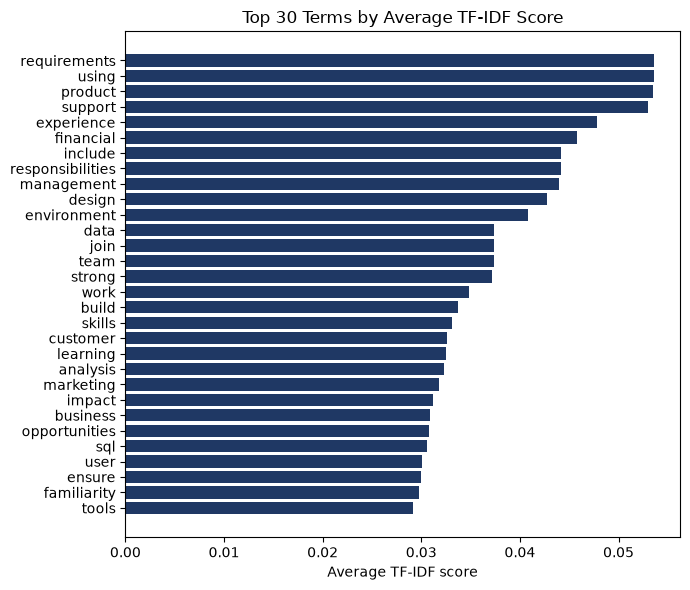

Of the top 50 TF-IDF terms, 1 matched the skill dictionary:
['sql']


In [4]:
# Fit TF-IDF
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)
X = vectorizer.fit_transform(df["clean_description"])
print("TF-IDF matrix shape:", X.shape)

# Find highest-scoring terms (by average TF-IDF score across all documents)
feature_names = np.array(vectorizer.get_feature_names_out())
mean_tfidf = np.asarray(X.mean(axis=0)).flatten()

tfidf_ranking = pd.DataFrame({
    "term": feature_names,
    "avg_tfidf_score": mean_tfidf
}).sort_values("avg_tfidf_score", ascending=False).reset_index(drop=True)

top_terms = tfidf_ranking.head(30)
print(top_terms)

# Plot top terms
plt.figure(figsize=(7, 6))
plt.barh(top_terms["term"][::-1], top_terms["avg_tfidf_score"][::-1], color="#1F3864")
plt.xlabel("Average TF-IDF score")
plt.title("Top 30 Terms by Average TF-IDF Score")
plt.tight_layout()
plt.show()

# Compare: Dictionary skills vs TF-IDF keywords
dictionary_skills = [
    "python", "sql", "java", "scala", "r", "excel", "tableau", "aws", "azure", "gcp",
    "spark", "hadoop", "docker", "kubernetes", "git", "linux", "nlp", "tensorflow",
    "pytorch", "keras", "pandas", "numpy", "sklearn", "powerbi", "airflow", "snowflake",
    "etl", "statistics", "mathematics", "communication", "leadership",
]

top_n = 50
top_terms_list = tfidf_ranking.head(top_n)["term"].tolist()
matched = [t for t in top_terms_list if t in dictionary_skills]

print(f"Of the top {top_n} TF-IDF terms, {len(matched)} matched the skill dictionary:")
print(matched)